# 🍽️Food Wastage Management System 

In [1]:
# ✅ Install dependencies
!pip install --quiet streamlit pyngrok pandas matplotlib sqlalchemy

import os, sys, sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("CWD:", os.getcwd())

Python: 3.10.9 | packaged by Anaconda, Inc. | (main, Mar  1 2023, 18:18:15) [MSC v.1916 64 bit (AMD64)]
Pandas: 1.5.3
CWD: C:\Users\Admin


## 1) Load CSVs & Create DB

In [2]:
CSV_FILES = ['providers_data.csv','receivers_data.csv','food_listings_data.csv','claims_data.csv']
missing = [f for f in CSV_FILES if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(f"Missing CSVs: {missing}")

providers = pd.read_csv('providers_data.csv')
receivers = pd.read_csv('receivers_data.csv')
food_listings = pd.read_csv('food_listings_data.csv')
claims = pd.read_csv('claims_data.csv')

DB_PATH = 'food_waste.db'
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

engine = create_engine(f'sqlite:///{DB_PATH}')
providers.to_sql('providers', engine, index=False)
receivers.to_sql('receivers', engine, index=False)
food_listings.to_sql('food_listings', engine, index=False)
claims.to_sql('claims', engine, index=False)

with sqlite3.connect(DB_PATH) as conn:
    print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn))

            name
0      providers
1      receivers
2  food_listings
3         claims


## 2) SQL Helper

In [3]:
def run_sql(q, params=None):
    with sqlite3.connect('food_waste.db') as conn:
        return pd.read_sql_query(q, conn, params=params)

run_sql("SELECT COUNT(*) AS n FROM providers;")

,n
0,1000


## 3) 15 Core SQL Queries

### 1) Providers & Receivers per City

In [4]:
run_sql('''SELECT p.City,
       COUNT(DISTINCT p.Provider_ID) AS Providers,
       COUNT(DISTINCT r.Receiver_ID) AS Receivers
FROM providers p
LEFT JOIN receivers r ON r.City = p.City
GROUP BY p.City
ORDER BY p.City;''')

,City,Providers,Receivers
0,Adambury,1,0
1,Adamsview,1,0
2,Adamsville,1,0
3,Aguirreville,1,0
4,Alexanderchester,1,0
...,...,...,...
958,Wrightville,1,0
959,Yatesside,1,0
960,Youngchester,1,0
961,Zimmermanton,1,0


### 2) Provider Type → Listings & Quantity

In [5]:
run_sql('''SELECT Provider_Type, COUNT(*) AS Total_Listings, SUM(Quantity) AS Total_Quantity
FROM food_listings
GROUP BY Provider_Type
ORDER BY Total_Quantity DESC, Total_Listings DESC;''')

,Provider_Type,Total_Listings,Total_Quantity
0,Restaurant,258,6923
1,Supermarket,267,6696
2,Catering Service,232,6116
3,Grocery Store,243,6059


### 3) Provider Contacts (all cities)

In [6]:
run_sql('''SELECT Provider_ID, Name, Type, Address, City, Contact
FROM providers
ORDER BY City, Name;''')

,Provider_ID,Name,Type,Address,City,Contact
0,338,Ibarra LLC,Catering Service,"064 Andrea Land Suite 946\nLake Melody, ME 49581",Adambury,6703380260
1,510,Lozano-Miller,Restaurant,"590 Michelle Brooks Apt. 406\nDanielburgh, TN ...",Adamsview,001-281-026-8022
2,757,Davis Ltd,Restaurant,"88279 Luis Throughway Apt. 639\nThomasberg, NM...",Adamsville,(112)122-3591x558
3,727,Rowe-Chen,Supermarket,"304 Leslie Key\nMiddletonfurt, IN 01285",Aguirreville,8228891240
4,962,Galloway-Henderson,Catering Service,Unit 2168 Box 9786\nDPO AA 06880,Alexanderchester,001-867-928-0212x3211
...,...,...,...,...,...,...
995,955,Williams PLC,Catering Service,0627 Keith Ferry Apt. 778\nNorth Melaniecheste...,Wrightville,(730)287-3289
996,760,Frederick LLC,Supermarket,"6559 Matthew Turnpike\nJohnsonchester, AK 98520",Yatesside,784.860.0232x137
997,691,"Obrien, King and Robinson",Restaurant,"560 Diane Place\nNorth Carla, SC 62821",Youngchester,+1-513-264-8229x419
998,928,Larson and Sons,Catering Service,"5591 Kathleen Route Apt. 687\nSouth Paul, NC 6...",Zimmermanton,152.836.4864


### 4) Receivers with Most Claims

In [7]:
run_sql('''SELECT r.Receiver_ID, r.Name, r.Type, r.City, COUNT(c.Claim_ID) AS Total_Claims
FROM receivers r
LEFT JOIN claims c ON c.Receiver_ID = r.Receiver_ID
GROUP BY r.Receiver_ID, r.Name, r.Type, r.City
ORDER BY Total_Claims DESC, r.Name;''')

,Receiver_ID,Name,Type,City,Total_Claims
0,800,Anthony Garcia,Individual,Brownbury,5
1,742,Matthew Webb,Charity,West David,5
2,276,Scott Hunter,Individual,Greenton,5
3,371,William Frederick,NGO,Port Dean,5
4,505,Alexandra Owens,NGO,Bradleyland,4
...,...,...,...,...,...
995,847,Wesley Myers,Shelter,Meganburgh,0
996,573,William Clark,Shelter,Port Courtneyland,0
997,501,William Davila,Individual,Gilbertborough,0
998,597,Willie Nichols,Charity,Jonesland,0


### 5) Total Quantity Available

In [8]:
run_sql('''SELECT SUM(Quantity) AS Total_Quantity FROM food_listings;''')

,Total_Quantity
0,25794


### 6) City with Most Listings

In [9]:
run_sql('''SELECT Location AS City, COUNT(Food_ID) AS Listings
FROM food_listings
GROUP BY Location
ORDER BY Listings DESC, Location;''')

,City,Listings
0,New Carol,6
1,South Kathryn,6
2,East Angela,5
3,Jimmyberg,5
4,Perezport,5
...,...,...
619,Williamland,1
620,Williamview,1
621,Wilsonport,1
622,Wilsonview,1


### 7) Most Common Food Types

In [10]:
run_sql('''SELECT Food_Type, COUNT(*) AS Items, SUM(Quantity) AS Total_Quantity
FROM food_listings
GROUP BY Food_Type
ORDER BY Items DESC, Total_Quantity DESC;''')

,Food_Type,Items,Total_Quantity
0,Vegetarian,336,8340
1,Vegan,334,8798
2,Non-Vegetarian,330,8656


### 8) Claims per Food Item

In [11]:
run_sql('''SELECT f.Food_ID, f.Food_Name, COUNT(c.Claim_ID) AS Claims
FROM food_listings f
LEFT JOIN claims c ON c.Food_ID = f.Food_ID
GROUP BY f.Food_ID, f.Food_Name
ORDER BY Claims DESC, f.Food_Name;''')

,Food_ID,Food_Name,Claims
0,486,Chicken,5
1,548,Fish,5
2,463,Soup,5
3,886,Bread,4
4,92,Chicken,4
...,...,...,...
995,130,Vegetables,0
996,121,Vegetables,0
997,91,Vegetables,0
998,82,Vegetables,0


### 9) Provider with Most Completed Claims

In [12]:
run_sql('''SELECT p.Provider_ID, p.Name, COUNT(c.Claim_ID) AS Completed_Claims
FROM providers p
JOIN food_listings f ON f.Provider_ID = p.Provider_ID
JOIN claims c ON c.Food_ID = f.Food_ID
WHERE c.Status = 'Completed'
GROUP BY p.Provider_ID, p.Name
ORDER BY Completed_Claims DESC, p.Name;''')

,Provider_ID,Name,Completed_Claims
0,709,Barry Group,5
1,596,"Barnes, Castro and Curtis",4
2,752,Butler-Richardson,4
3,241,"Harper, Blake and Alexander",4
4,967,Miller Inc,4
...,...,...,...
246,765,Wong-Wilson,1
247,206,Yoder-Murray,1
248,559,"Young, Moran and Morris",1
249,722,Young-Luna,1


### 10) Claims Status Breakdown (%)

In [13]:
run_sql('''SELECT Status, COUNT(*) AS Count,
       ROUND(100.0*COUNT(*)/(SELECT COUNT(*) FROM claims), 2) AS Percentage
FROM claims
GROUP BY Status
ORDER BY Count DESC;''')

,Status,Count,Percentage
0,Completed,339,33.9
1,Cancelled,336,33.6
2,Pending,325,32.5


### 11) Avg Quantity Claimed per Receiver

In [14]:
run_sql('''SELECT r.Receiver_ID, r.Name, ROUND(AVG(f.Quantity), 2) AS Avg_Quantity_Claimed
FROM receivers r
JOIN claims c ON c.Receiver_ID = r.Receiver_ID
JOIN food_listings f ON f.Food_ID = c.Food_ID
GROUP BY r.Receiver_ID, r.Name
ORDER BY Avg_Quantity_Claimed DESC;''')

,Receiver_ID,Name,Avg_Quantity_Claimed
0,99,Nancy Silva,50.0
1,282,Lisa Pitts,50.0
2,429,Daniel Williams,50.0
3,567,Peggy Knight,50.0
4,616,Christopher Wright,50.0
...,...,...,...
619,214,Corey Rodriguez,2.0
620,746,Kenneth Barnes,2.0
621,766,John Reynolds,2.0
622,765,Joshua Hooper,1.0


### 12) Most Claimed Meal Type

In [15]:
run_sql('''SELECT f.Meal_Type, COUNT(c.Claim_ID) AS Total_Claims
FROM food_listings f
JOIN claims c ON c.Food_ID = f.Food_ID
GROUP BY f.Meal_Type
ORDER BY Total_Claims DESC;''')

,Meal_Type,Total_Claims
0,Breakfast,278
1,Lunch,250
2,Snacks,240
3,Dinner,232


### 13) Total Donated per Provider

In [16]:
run_sql('''SELECT p.Provider_ID, p.Name, SUM(f.Quantity) AS Total_Quantity_Donated
FROM providers p
JOIN food_listings f ON f.Provider_ID = p.Provider_ID
GROUP BY p.Provider_ID, p.Name
ORDER BY Total_Quantity_Donated DESC, p.Name;''')

,Provider_ID,Name,Total_Quantity_Donated
0,709,Barry Group,179
1,306,"Evans, Wright and Mitchell",158
2,655,Smith Group,150
3,315,Nelson LLC,142
4,678,Ruiz-Oneal,140
...,...,...,...
632,258,Gonzales-Moore,1
633,745,"Martinez, Armstrong and Carroll",1
634,870,Mcgee PLC,1
635,184,Norris-Townsend,1


### 14) Availability by City (Quantity)

In [17]:
run_sql('''SELECT Location AS City, SUM(Quantity) AS Total_Available
FROM food_listings
GROUP BY Location
ORDER BY Total_Available DESC, Location;''')

,City,Total_Available
0,South Kathryn,179
1,Jonathanstad,169
2,New Carol,167
3,North Keith,158
4,Jimmyberg,150
...,...,...
619,West Lucasville,2
620,Lake Anthonyport,1
621,New Hollyfurt,1
622,New Monicaside,1


### 15) Top 5 Receivers by Completed Claims

In [18]:
run_sql('''SELECT r.Receiver_ID, r.Name, COUNT(c.Claim_ID) AS Completed_Claims
FROM receivers r
JOIN claims c ON c.Receiver_ID = r.Receiver_ID
WHERE c.Status = 'Completed'
GROUP BY r.Receiver_ID, r.Name
ORDER BY Completed_Claims DESC, r.Name
LIMIT 5;''')

,Receiver_ID,Name,Completed_Claims
0,505,Alexandra Owens,3
1,45,Derek Potter,3
2,482,Timothy Garrett,3
3,440,Alexander Walsh,2
4,90,Alvin West,2


## 4) Charts

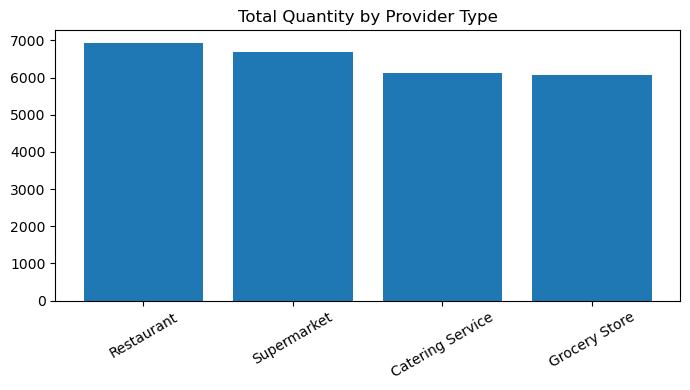

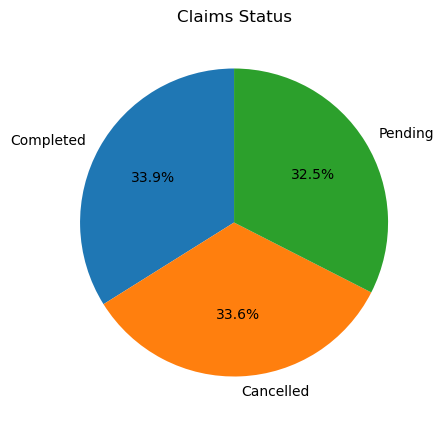

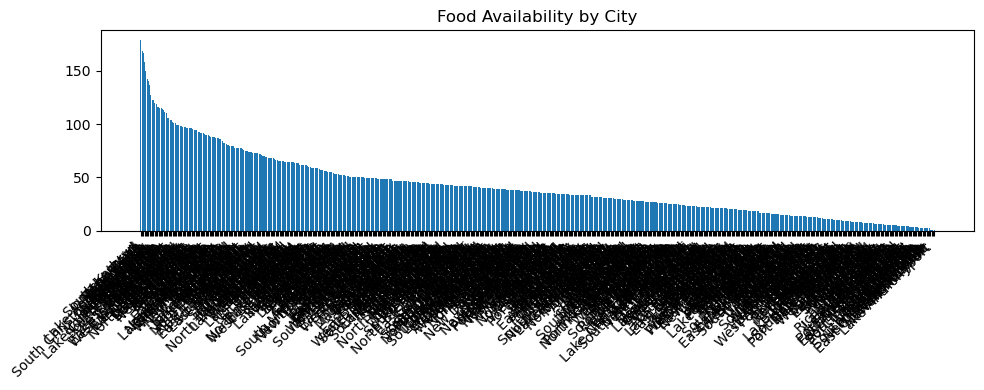

In [19]:
# Chart A
df_a = run_sql("SELECT Provider_Type, SUM(Quantity) AS Total_Quantity FROM food_listings GROUP BY Provider_Type ORDER BY Total_Quantity DESC")
plt.figure(figsize=(7,4)); plt.bar(df_a['Provider_Type'].astype(str), df_a['Total_Quantity']); plt.title('Total Quantity by Provider Type'); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

# Chart B
df_b = run_sql("SELECT Status, COUNT(*) AS Count FROM claims GROUP BY Status ORDER BY Count DESC")
plt.figure(figsize=(5,5)); plt.pie(df_b['Count'], labels=df_b['Status'], autopct='%1.1f%%', startangle=90); plt.title('Claims Status'); plt.show()

# Chart C
df_c = run_sql("SELECT Location AS City, SUM(Quantity) AS Total_Available FROM food_listings GROUP BY Location ORDER BY Total_Available DESC")
plt.figure(figsize=(10,4)); plt.bar(df_c['City'].astype(str), df_c['Total_Available']); plt.title('Food Availability by City'); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 5) Generate `app.py` (Streamlit)

In [20]:

import streamlit as st
import pandas as pd
import sqlite3
from datetime import date, datetime

st.set_page_config(page_title="Local Food Wastage Management", page_icon="🍽️", layout="wide")
st.title("🍽️ Local Food Wastage Management System")

@st.cache_resource
def get_conn():
    return sqlite3.connect("food_waste.db", check_same_thread=False)

def run_sql(q, params=None):
    conn = get_conn()
    return pd.read_sql_query(q, conn, params=params)

def exec_sql(q, params=None):
    conn = get_conn()
    cur = conn.cursor()
    cur.execute(q, params or [])
    conn.commit()
    return cur.lastrowid

tab = st.sidebar.radio("Go to", ["Listings", "Providers", "Receivers", "Claims", "SQL Insights"])

if tab == "Listings":
    st.subheader("Available Food Listings")
    col1, col2, col3, col4 = st.columns(4)
    with col1:
        city = st.text_input("Filter by City (Location contains)")
    with col2:
        provider_name = st.text_input("Filter Provider Name (contains)")
    with col3:
        food_type = st.text_input("Filter Food Type (e.g., Vegetarian)")
    with col4:
        meal_type = st.text_input("Filter Meal Type (Breakfast/Lunch/Dinner/Snacks)")

    base = """
      SELECT f.Food_ID, f.Food_Name, f.Quantity, f.Expiry_Date,
             f.Provider_ID, f.Provider_Type, f.Location, f.Food_Type, f.Meal_Type,
             p.Name AS Provider_Name, p.Contact AS Provider_Contact
      FROM food_listings f
      LEFT JOIN providers p ON p.Provider_ID = f.Provider_ID
      WHERE 1=1
    """
    params = []
    if city:
        base += " AND f.Location LIKE ?"
        params.append(f"%{city}%")
    if provider_name:
        base += " AND p.Name LIKE ?"
        params.append(f"%{provider_name}%")
    if food_type:
        base += " AND f.Food_Type LIKE ?"
        params.append(f"%{food_type}%")
    if meal_type:
        base += " AND f.Meal_Type LIKE ?"
        params.append(f"%{meal_type}%")
    base += " ORDER BY f.Expiry_Date ASC, f.Food_Name"

    st.dataframe(run_sql(base, params), use_container_width=True)

    with st.expander("➕ Add New Listing"):
        p_id = st.number_input("Provider_ID", min_value=1, step=1)
        food_name = st.text_input("Food_Name")
        qty = st.number_input("Quantity", min_value=1, step=1)
        exp = st.date_input("Expiry_Date", value=date.today())
        ptype = st.text_input("Provider_Type")
        loc = st.text_input("Location")
        ftype = st.text_input("Food_Type")
        mtype = st.text_input("Meal_Type")
        if st.button("Create Listing"):
            exec_sql(
                "INSERT INTO food_listings (Food_Name, Quantity, Expiry_Date, Provider_ID, Provider_Type, Location, Food_Type, Meal_Type) VALUES (?, ?, ?, ?, ?, ?, ?, ?)",
                [food_name, int(qty), str(exp), int(p_id), ptype, loc, ftype, mtype]
            )
            st.success("Listing added. Refresh the page to see it.")

    with st.expander("✏️ Update or 🗑️ Delete Listing"):
        lid = st.number_input("Food_ID", min_value=1, step=1)
        new_qty = st.number_input("New Quantity", min_value=0, step=1)
        if st.button("Update Quantity"):
            exec_sql("UPDATE food_listings SET Quantity=? WHERE Food_ID=?", [int(new_qty), int(lid)])
            st.success("Updated quantity.")
        if st.button("Delete Listing"):
            exec_sql("DELETE FROM food_listings WHERE Food_ID=?", [int(lid)])
            st.warning("Listing deleted.")

elif tab == "Providers":
    st.subheader("Providers")
    st.dataframe(run_sql("SELECT * FROM providers ORDER BY City, Name"), use_container_width=True)
    with st.expander("➕ Add Provider"):
        name = st.text_input("Name")
        ptype = st.text_input("Type")
        addr = st.text_input("Address")
        city = st.text_input("City")
        contact = st.text_input("Contact")
        if st.button("Create Provider"):
            exec_sql("INSERT INTO providers (Name, Type, Address, City, Contact) VALUES (?, ?, ?, ?, ?)", [name, ptype, addr, city, contact])
            st.success("Provider created.")

elif tab == "Receivers":
    st.subheader("Receivers")
    st.dataframe(run_sql("SELECT * FROM receivers ORDER BY City, Name"), use_container_width=True)
    with st.expander("➕ Add Receiver"):
        name = st.text_input("Name")
        rtype = st.text_input("Type")
        city = st.text_input("City")
        contact = st.text_input("Contact")
        if st.button("Create Receiver"):
            exec_sql("INSERT INTO receivers (Name, Type, City, Contact) VALUES (?, ?, ?, ?)", [name, rtype, city, contact])
            st.success("Receiver created.")

elif tab == "Claims":
    st.subheader("Claims")
    st.dataframe(run_sql("""
        SELECT c.Claim_ID, c.Food_ID, c.Receiver_ID, c.Status, c.Timestamp,
               r.Name AS Receiver_Name, f.Food_Name
        FROM claims c
        LEFT JOIN receivers r ON r.Receiver_ID = c.Receiver_ID
        LEFT JOIN food_listings f ON f.Food_ID = c.Food_ID
        ORDER BY c.Timestamp DESC
    """), use_container_width=True)
    with st.expander("➕ Create Claim"):
        food_id = st.number_input("Food_ID", min_value=1, step=1)
        recv_id = st.number_input("Receiver_ID", min_value=1, step=1)
        status = st.selectbox("Status", ["Pending", "Completed", "Cancelled"])
        ts = st.text_input("Timestamp (YYYY-MM-DD HH:MM:SS) - leave empty for now")
        if st.button("Create Claim"):
            if not ts:
                ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            exec_sql("INSERT INTO claims (Food_ID, Receiver_ID, Status, Timestamp) VALUES (?, ?, ?, ?)", [int(food_id), int(recv_id), status, ts])
            st.success("Claim created.")

elif tab == "SQL Insights":
    st.subheader("Key SQL Insights (15 queries)")
    queries = {
        "Providers & Receivers per City": "SELECT p.City, COUNT(DISTINCT p.Provider_ID) AS Providers, COUNT(DISTINCT r.Receiver_ID) AS Receivers FROM providers p LEFT JOIN receivers r ON r.City=p.City GROUP BY p.City ORDER BY p.City",
        "Provider Type → Listings & Quantity": "SELECT Provider_Type, COUNT(*) AS Total_Listings, SUM(Quantity) AS Total_Quantity FROM food_listings GROUP BY Provider_Type ORDER BY Total_Quantity DESC",
        "Receivers with Most Claims": "SELECT r.Name, COUNT(c.Claim_ID) AS Total_Claims FROM receivers r LEFT JOIN claims c ON c.Receiver_ID=r.Receiver_ID GROUP BY r.Name ORDER BY Total_Claims DESC",
        "Total Quantity Available": "SELECT SUM(Quantity) AS Total_Quantity FROM food_listings",
        "Listings by City": "SELECT Location AS City, COUNT(Food_ID) AS Listings FROM food_listings GROUP BY Location ORDER BY Listings DESC",
        "Common Food Types": "SELECT Food_Type, COUNT(*) AS Items, SUM(Quantity) AS Total_Quantity FROM food_listings GROUP BY Food_Type ORDER BY Items DESC",
        "Claims per Food Item": "SELECT f.Food_Name, COUNT(c.Claim_ID) AS Claims FROM food_listings f LEFT JOIN claims c ON c.Food_ID=f.Food_ID GROUP BY f.Food_Name ORDER BY Claims DESC",
        "Top Providers by Completed Claims": "SELECT p.Name, COUNT(c.Claim_ID) AS Completed_Claims FROM providers p JOIN food_listings f ON f.Provider_ID=p.Provider_ID JOIN claims c ON c.Food_ID=f.Food_ID WHERE c.Status='Completed' GROUP BY p.Name ORDER BY Completed_Claims DESC",
        "Claim Status %": "SELECT Status, COUNT(*) AS Count, ROUND(100.0*COUNT(*)/(SELECT COUNT(*) FROM claims),2) AS Percentage FROM claims GROUP BY Status ORDER BY Count DESC",
        "Avg Quantity per Receiver": "SELECT r.Name, ROUND(AVG(f.Quantity),2) AS Avg_Quantity_Claimed FROM receivers r JOIN claims c ON c.Receiver_ID=r.Receiver_ID JOIN food_listings f ON f.Food_ID=c.Food_ID GROUP BY r.Name ORDER BY Avg_Quantity_Claimed DESC",
        "Most Claimed Meal Type": "SELECT f.Meal_Type, COUNT(c.Claim_ID) AS Total_Claims FROM food_listings f JOIN claims c ON c.Food_ID=f.Food_ID GROUP BY f.Meal_Type ORDER BY Total_Claims DESC",
        "Total Donated by Provider": "SELECT p.Name, SUM(f.Quantity) AS Total_Quantity_Donated FROM providers p JOIN food_listings f ON f.Provider_ID=p.Provider_ID GROUP BY p.Name ORDER BY Total_Quantity_Donated DESC",
        "Availability by City": "SELECT Location AS City, SUM(Quantity) AS Total_Available FROM food_listings GROUP BY Location ORDER BY Total_Available DESC",
        "Top 5 Receivers (Completed)": "SELECT r.Name, COUNT(c.Claim_ID) AS Completed_Claims FROM receivers r JOIN claims c ON c.Receiver_ID=r.Receiver_ID WHERE c.Status='Completed' GROUP BY r.Name ORDER BY Completed_Claims DESC LIMIT 5"
    }
    for title, q in queries.items():
        st.markdown(f"### {title}")
        st.dataframe(run_sql(q), use_container_width=True)

Overwriting app.py


## 6) Screenshots Streamlit app

C:\Labmentix\Project Folder


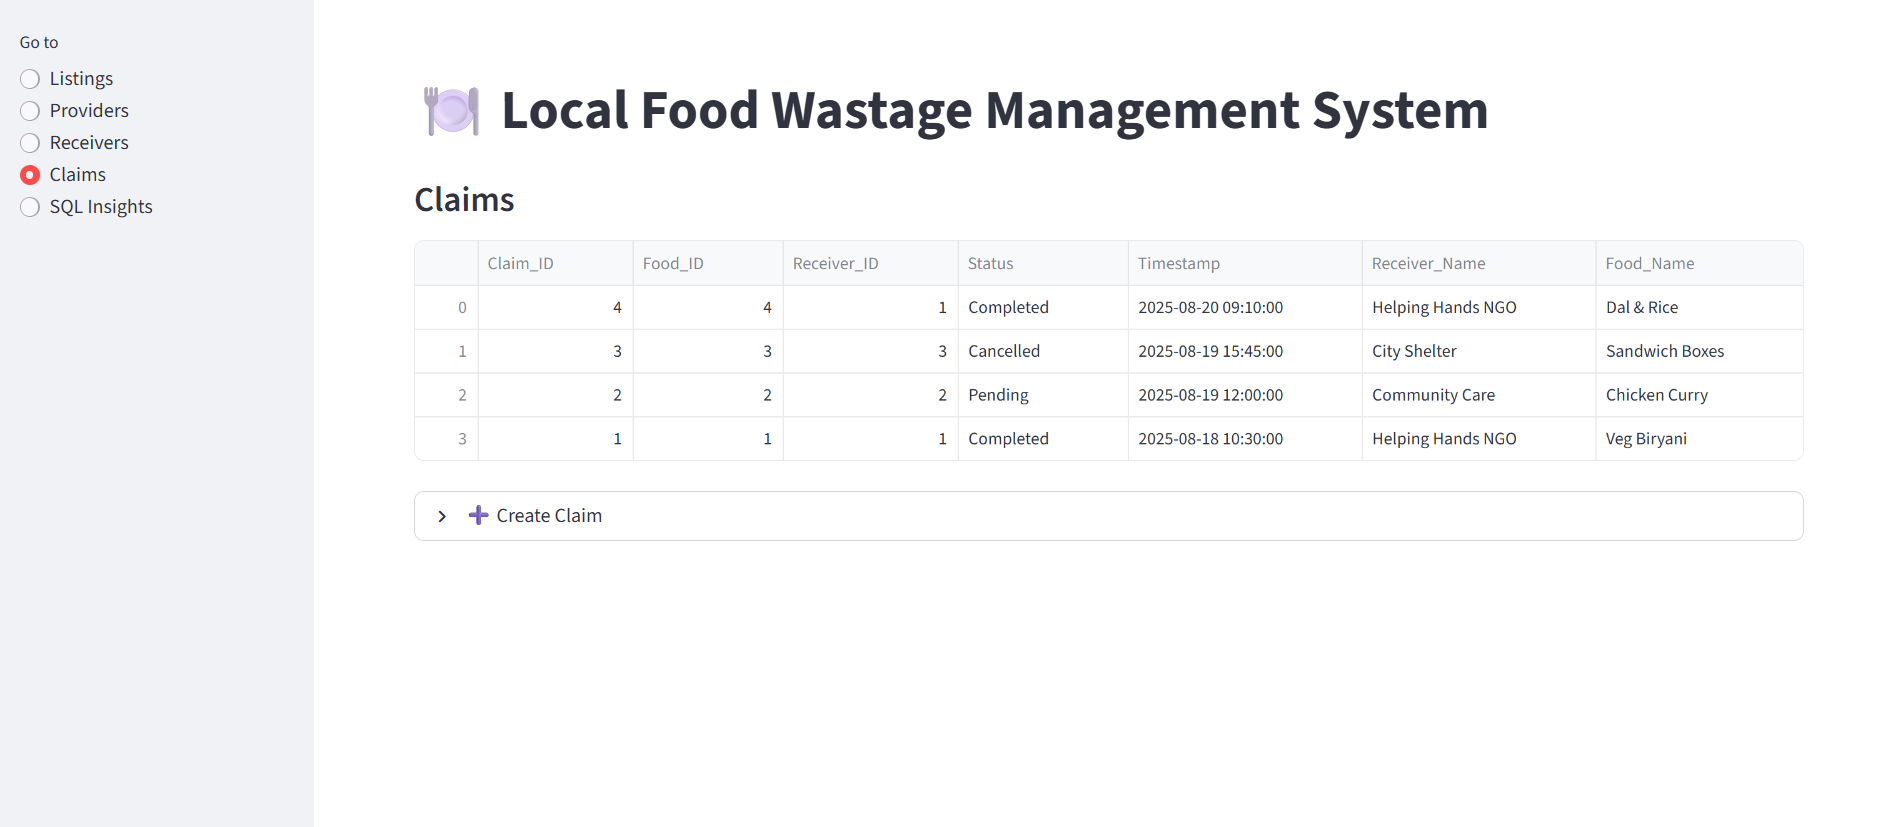

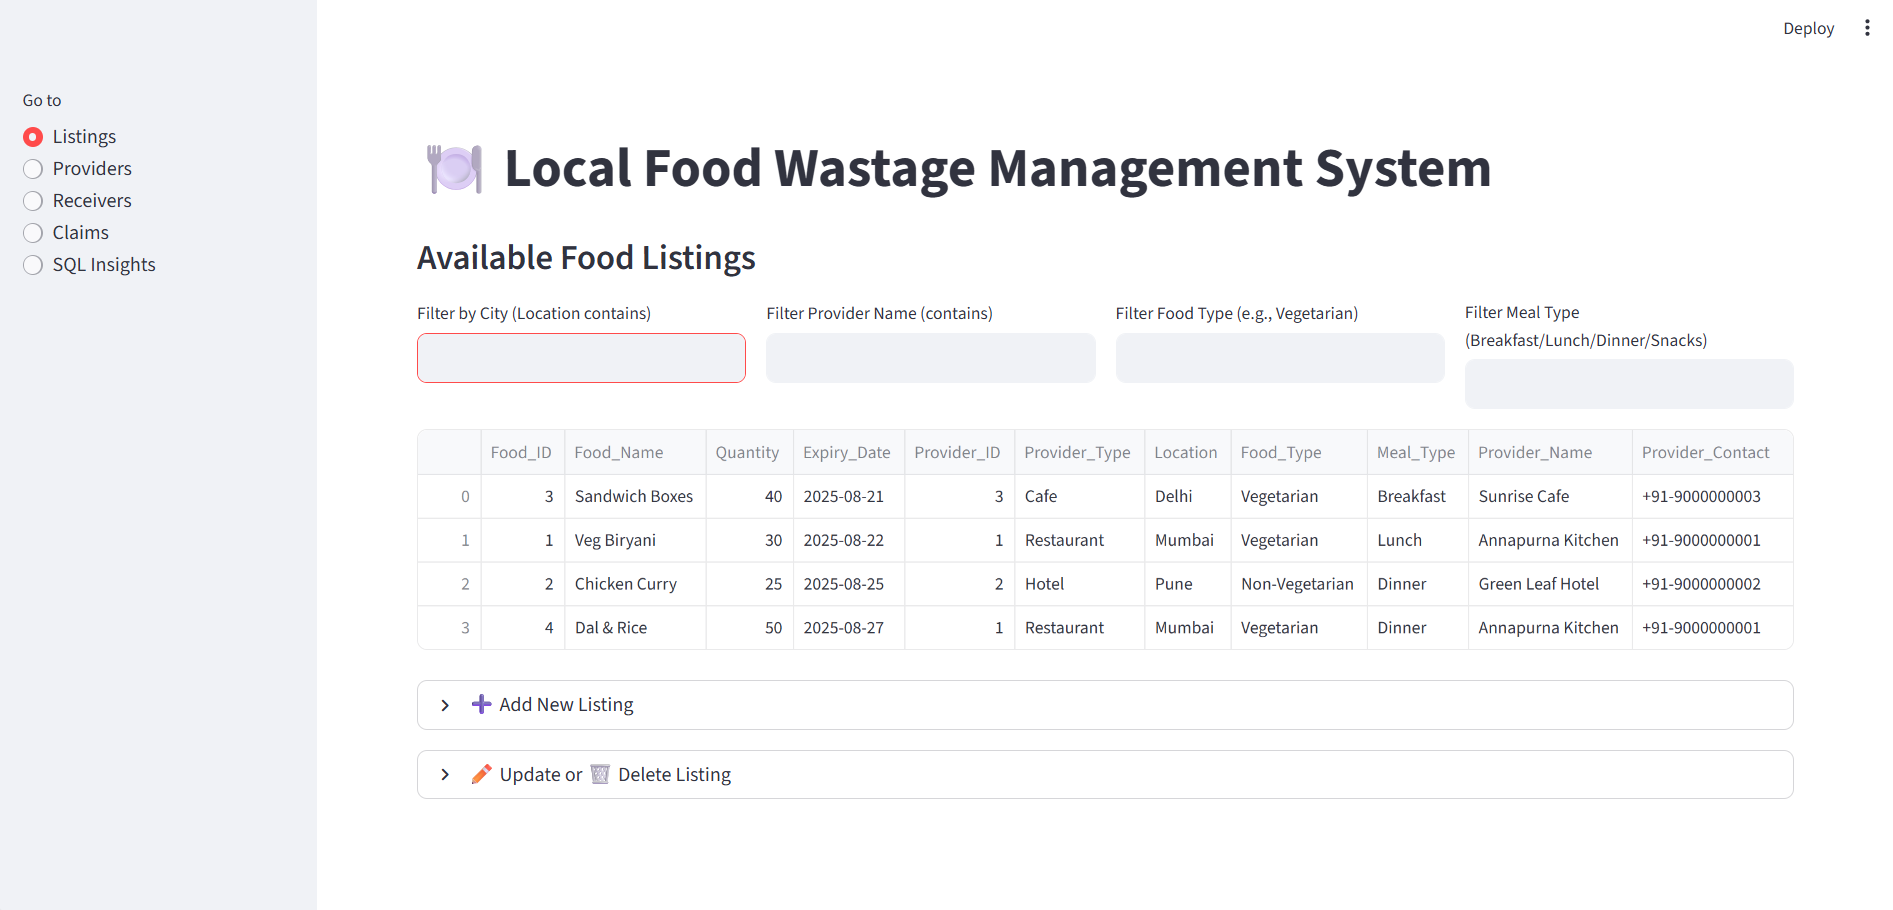

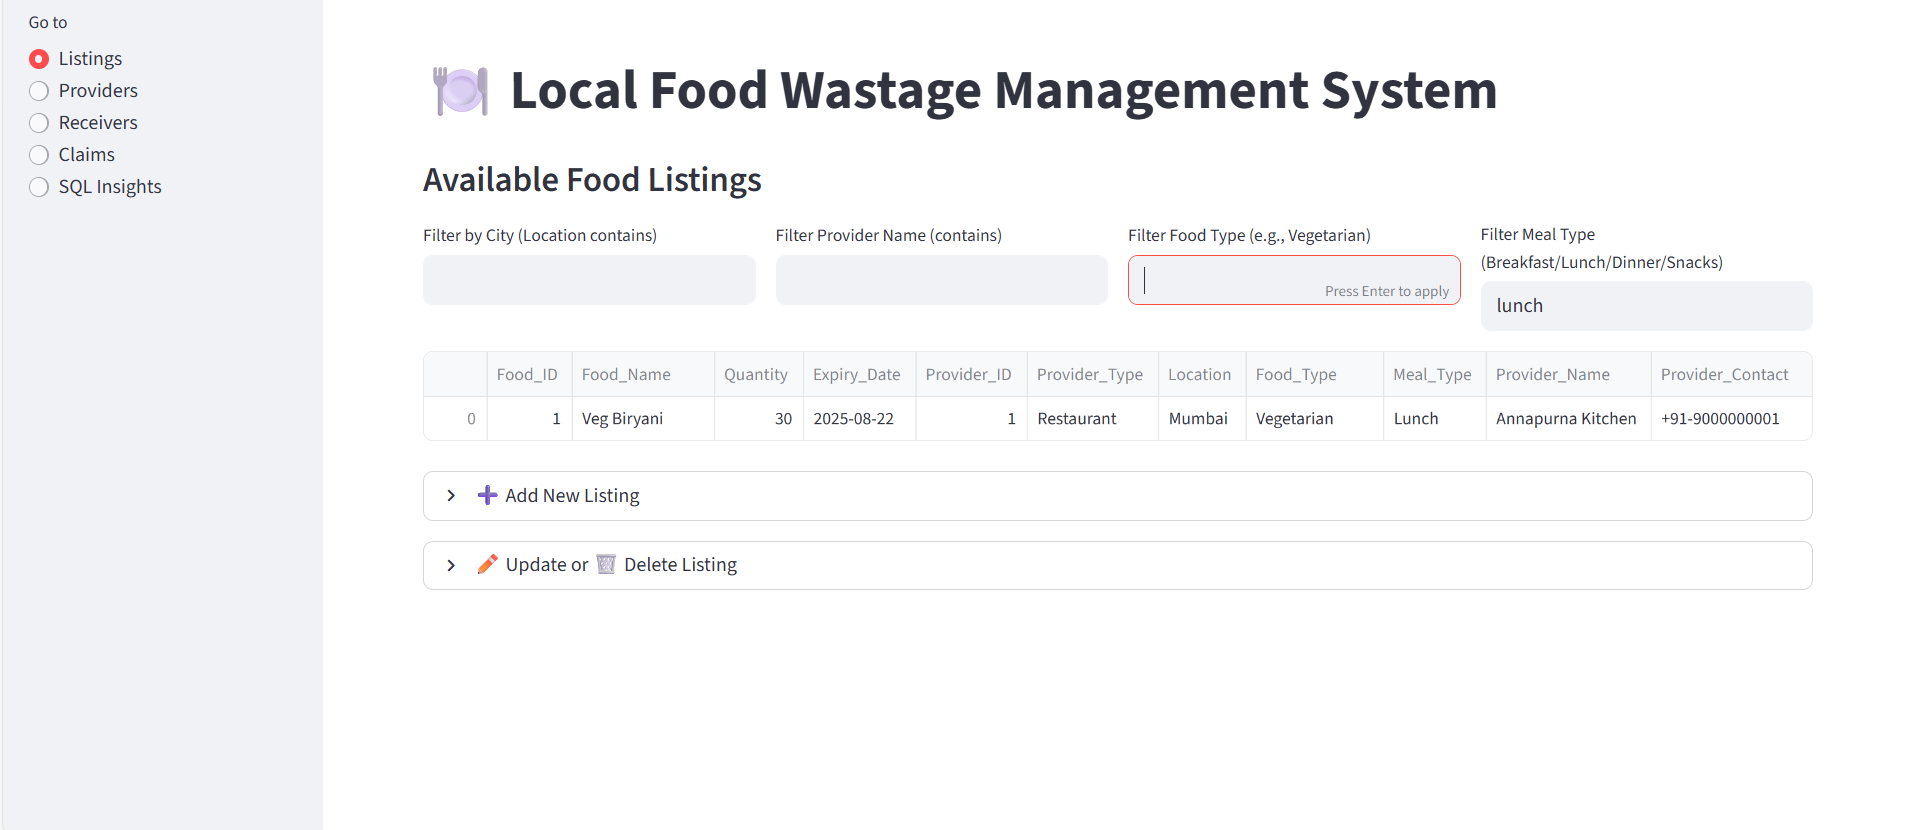

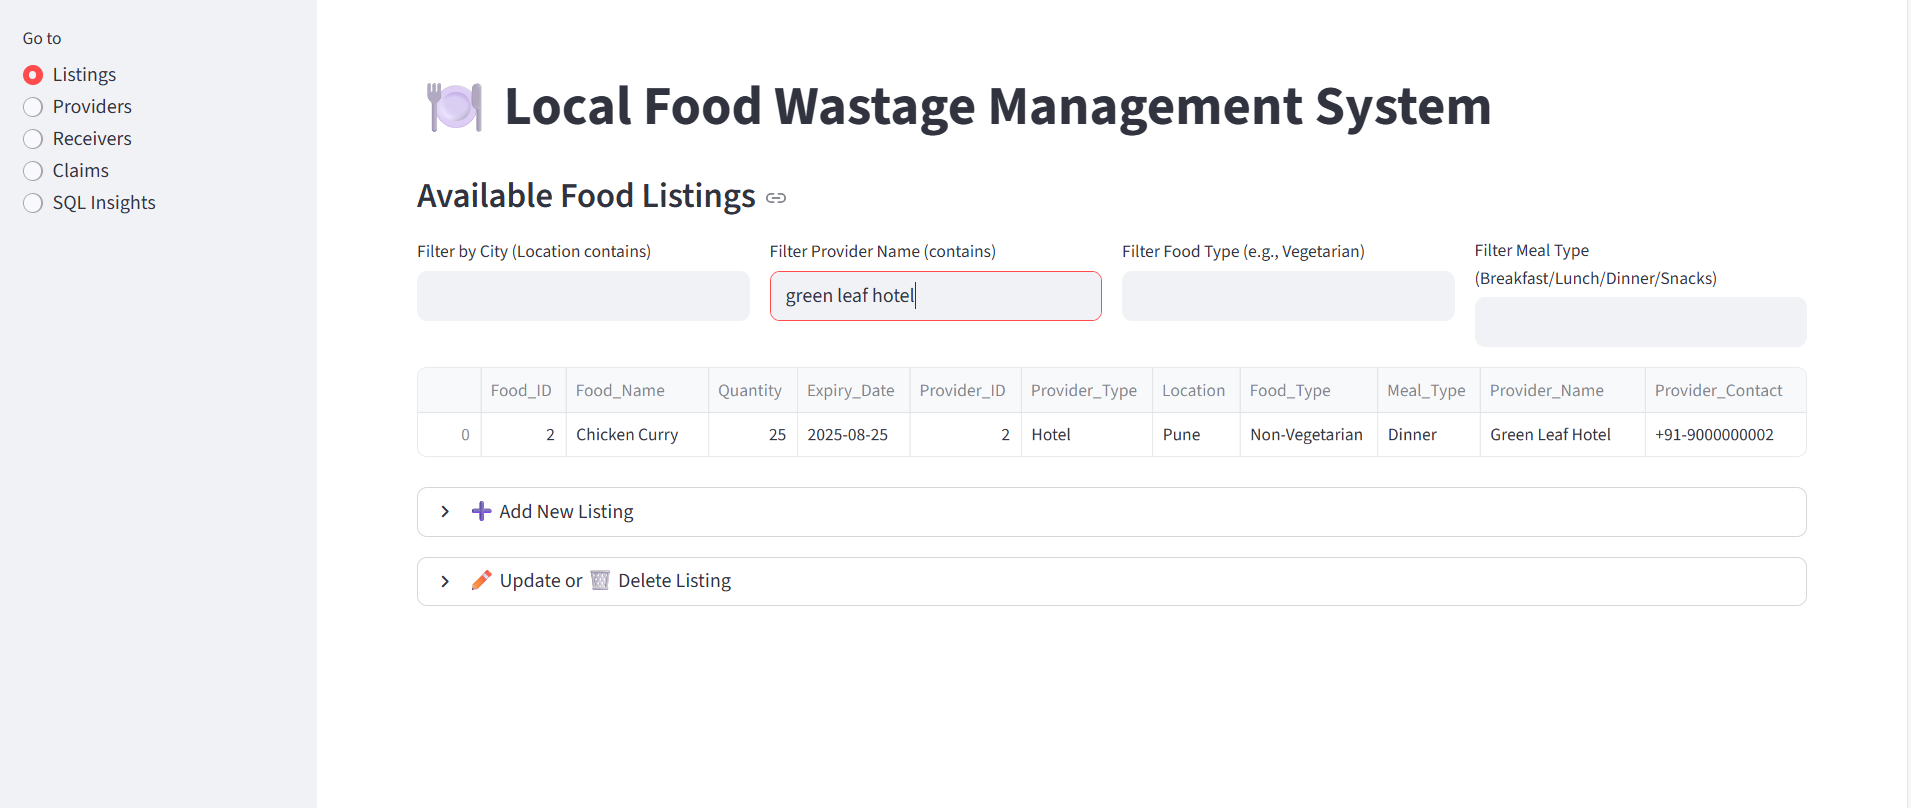

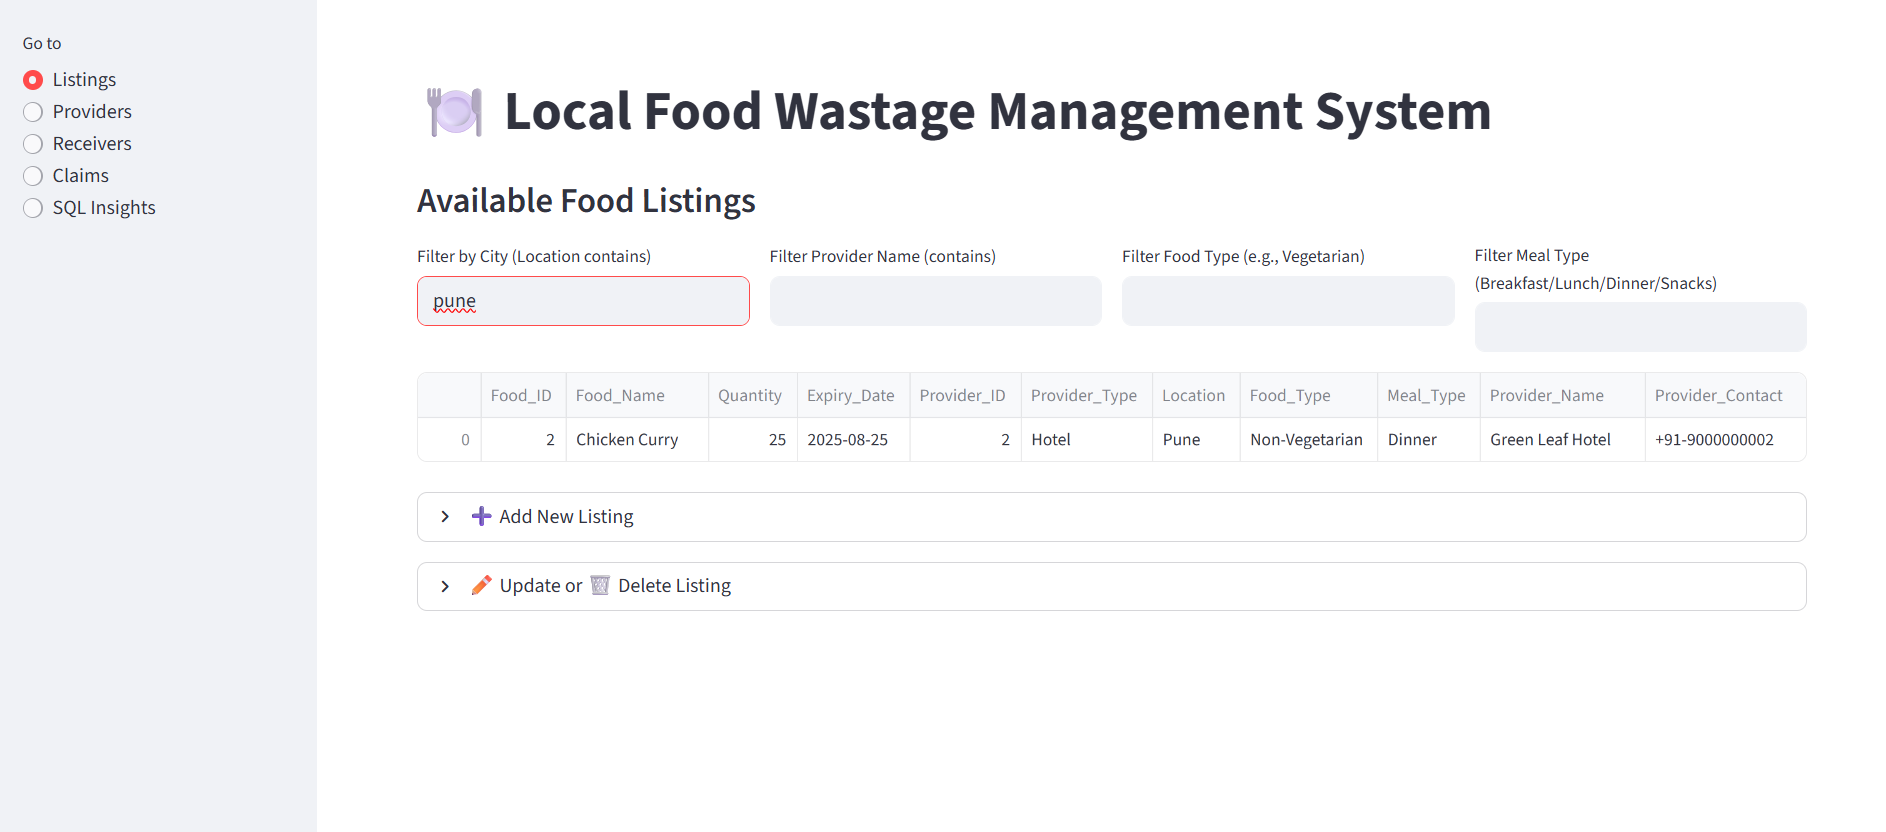

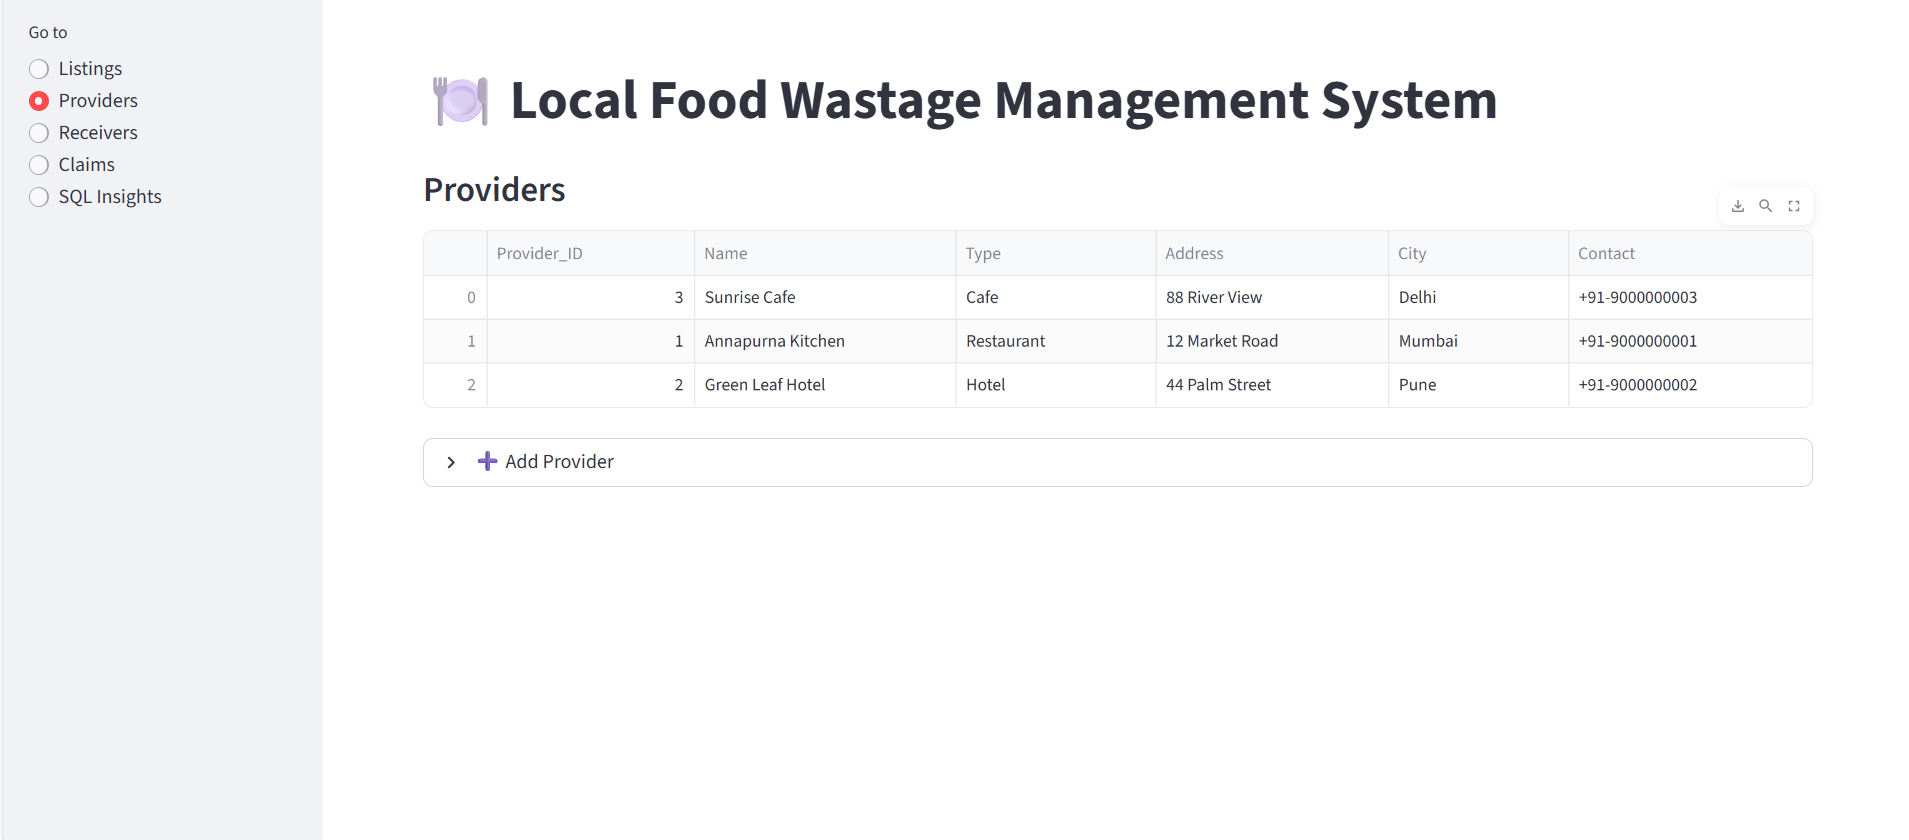

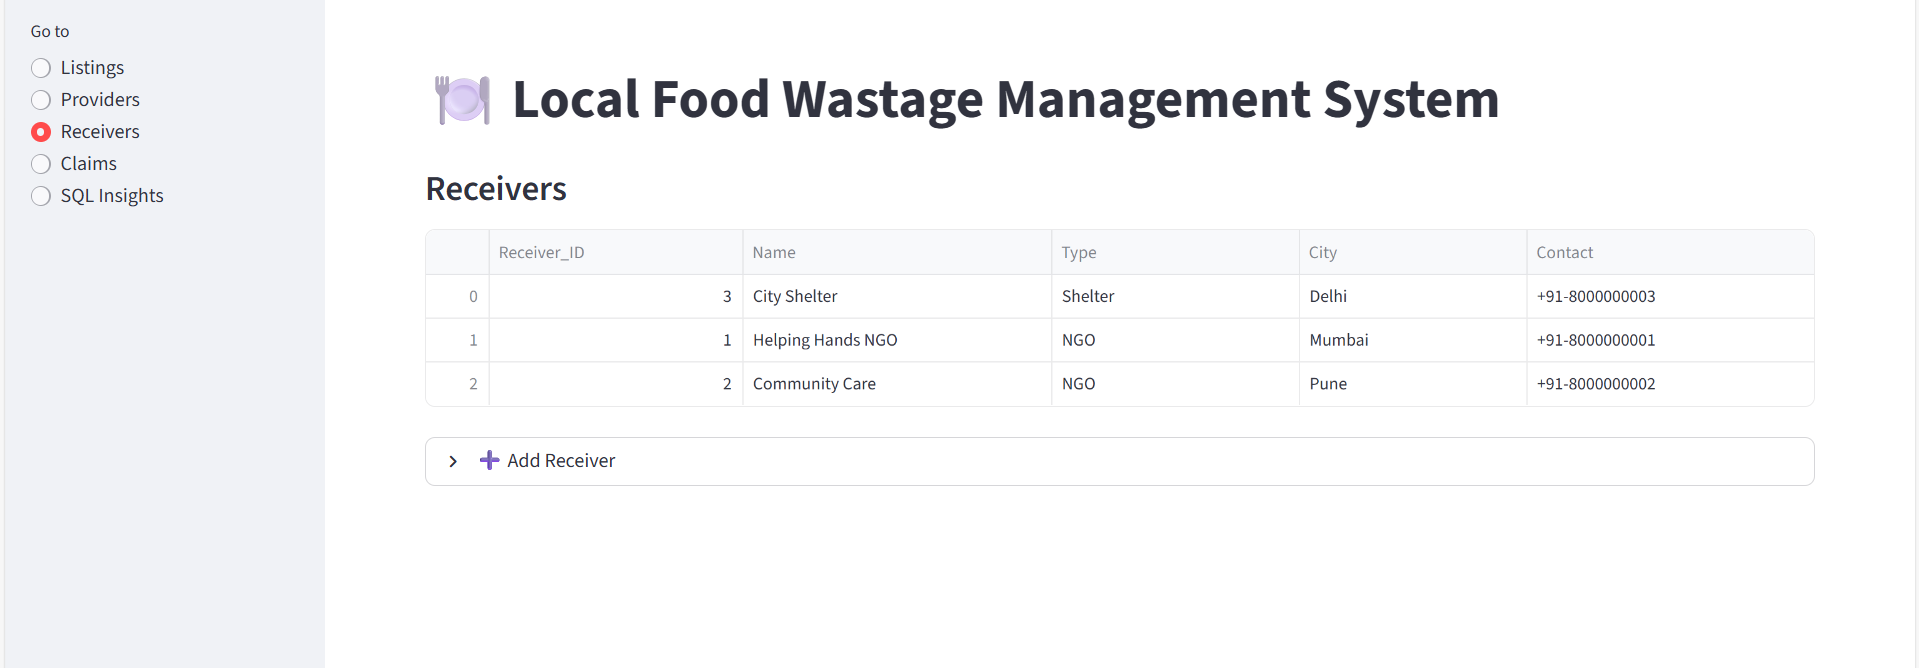

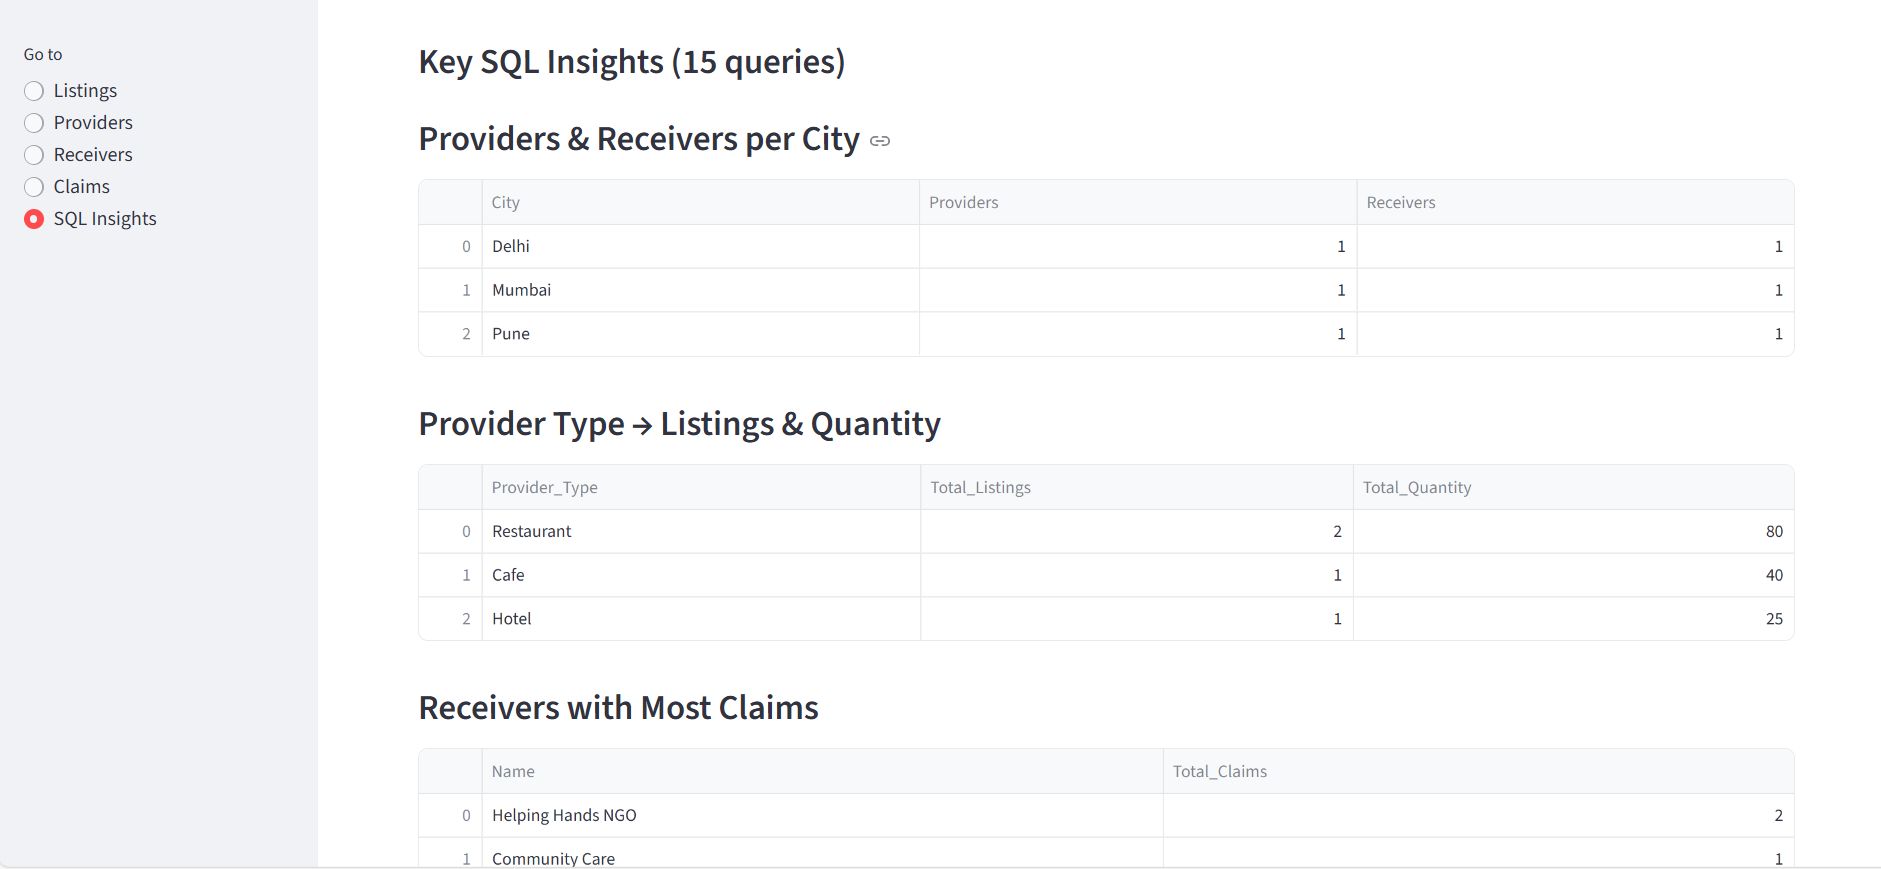

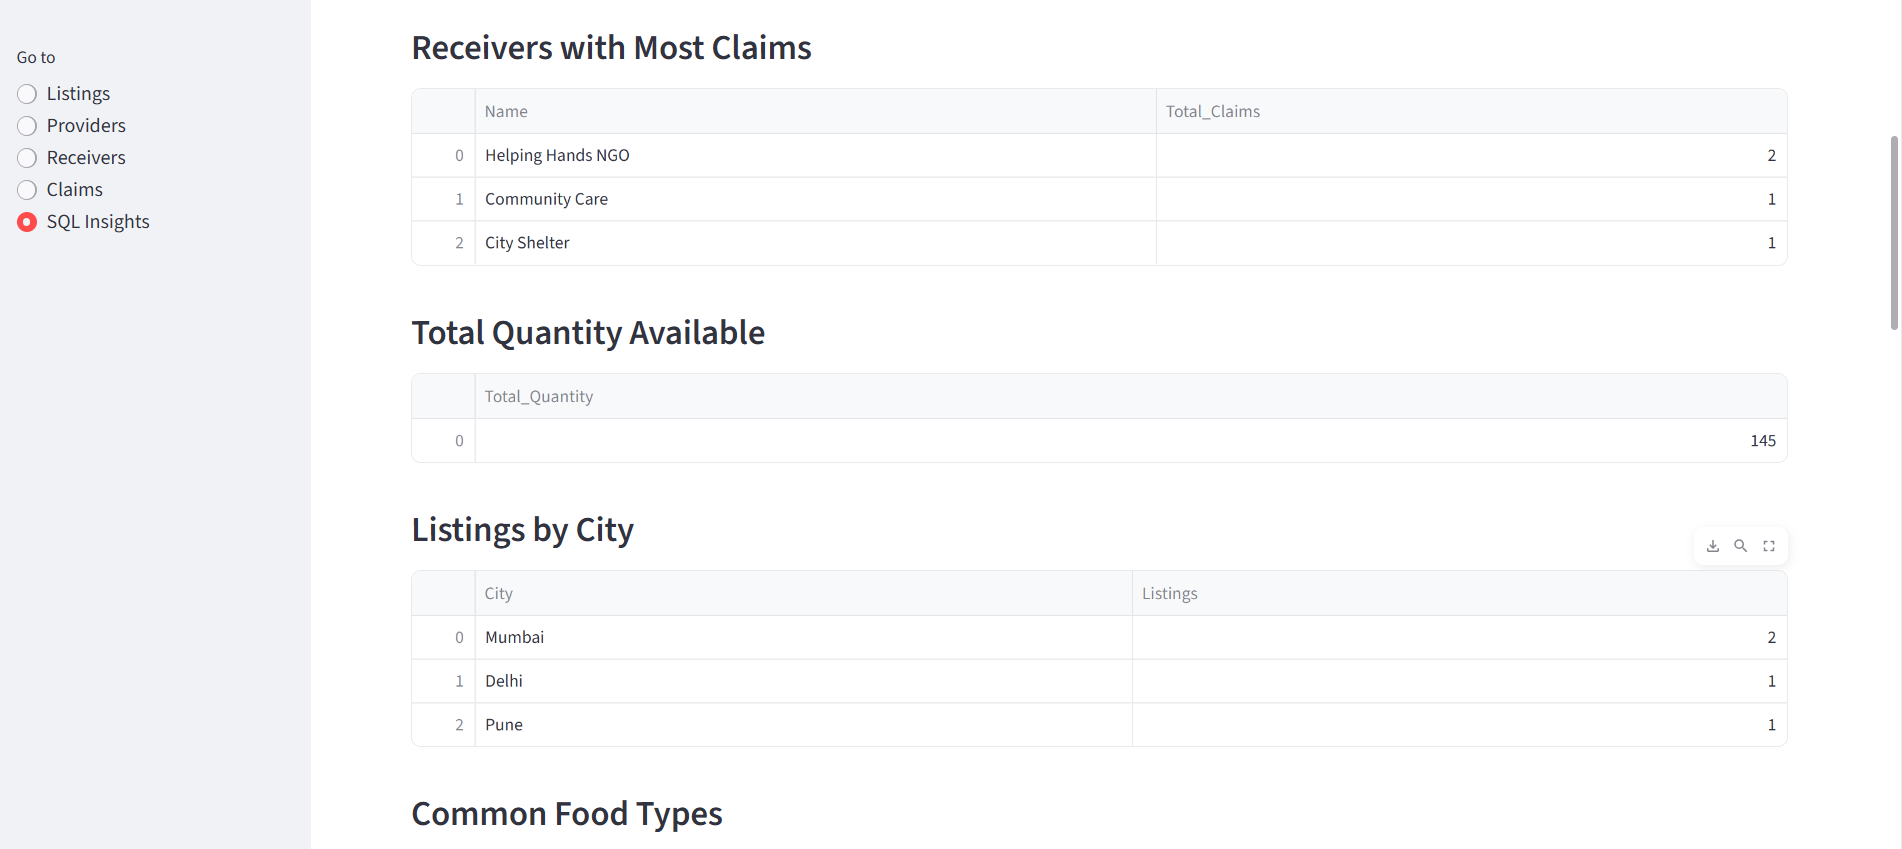

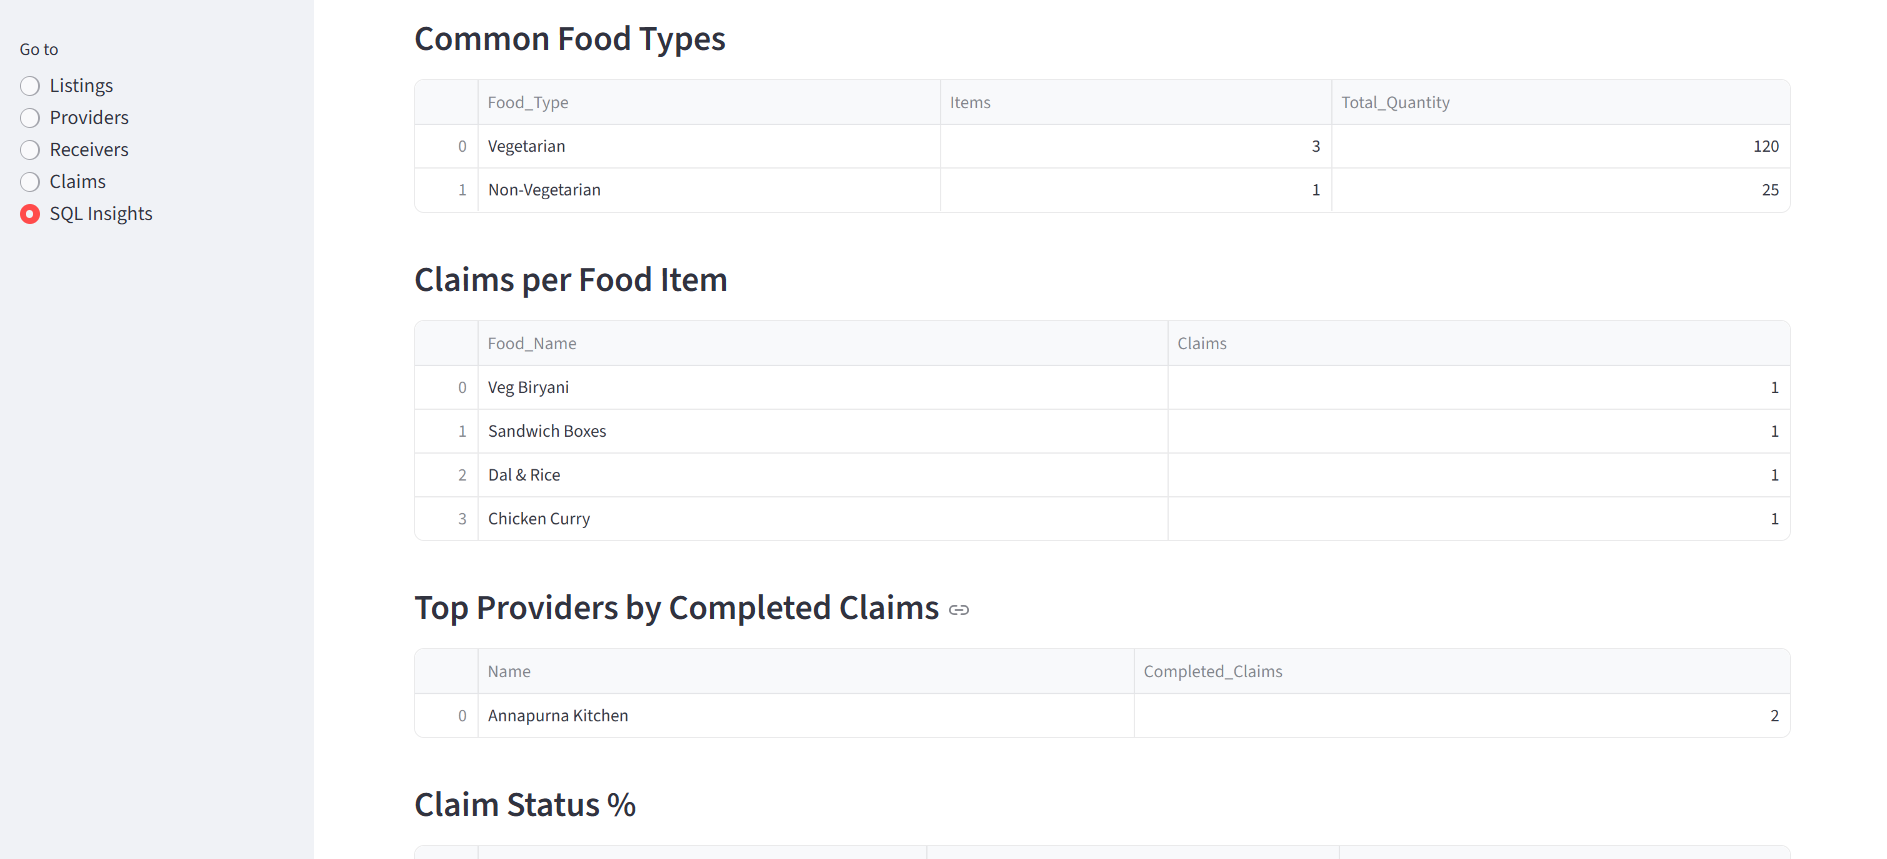

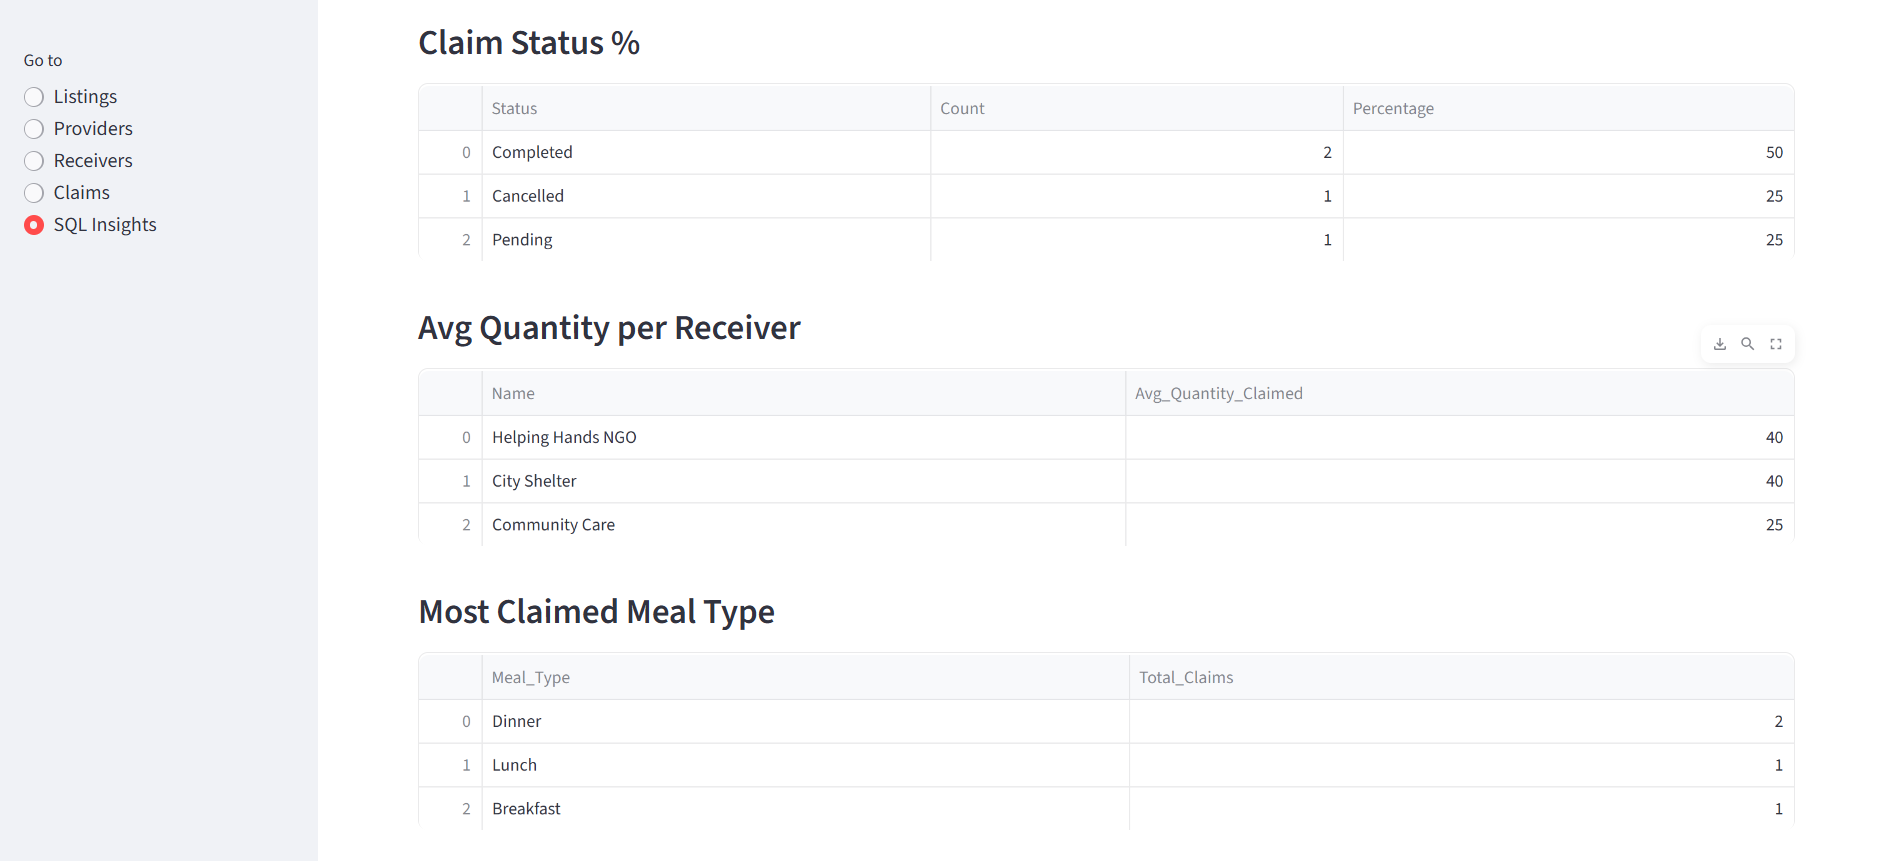

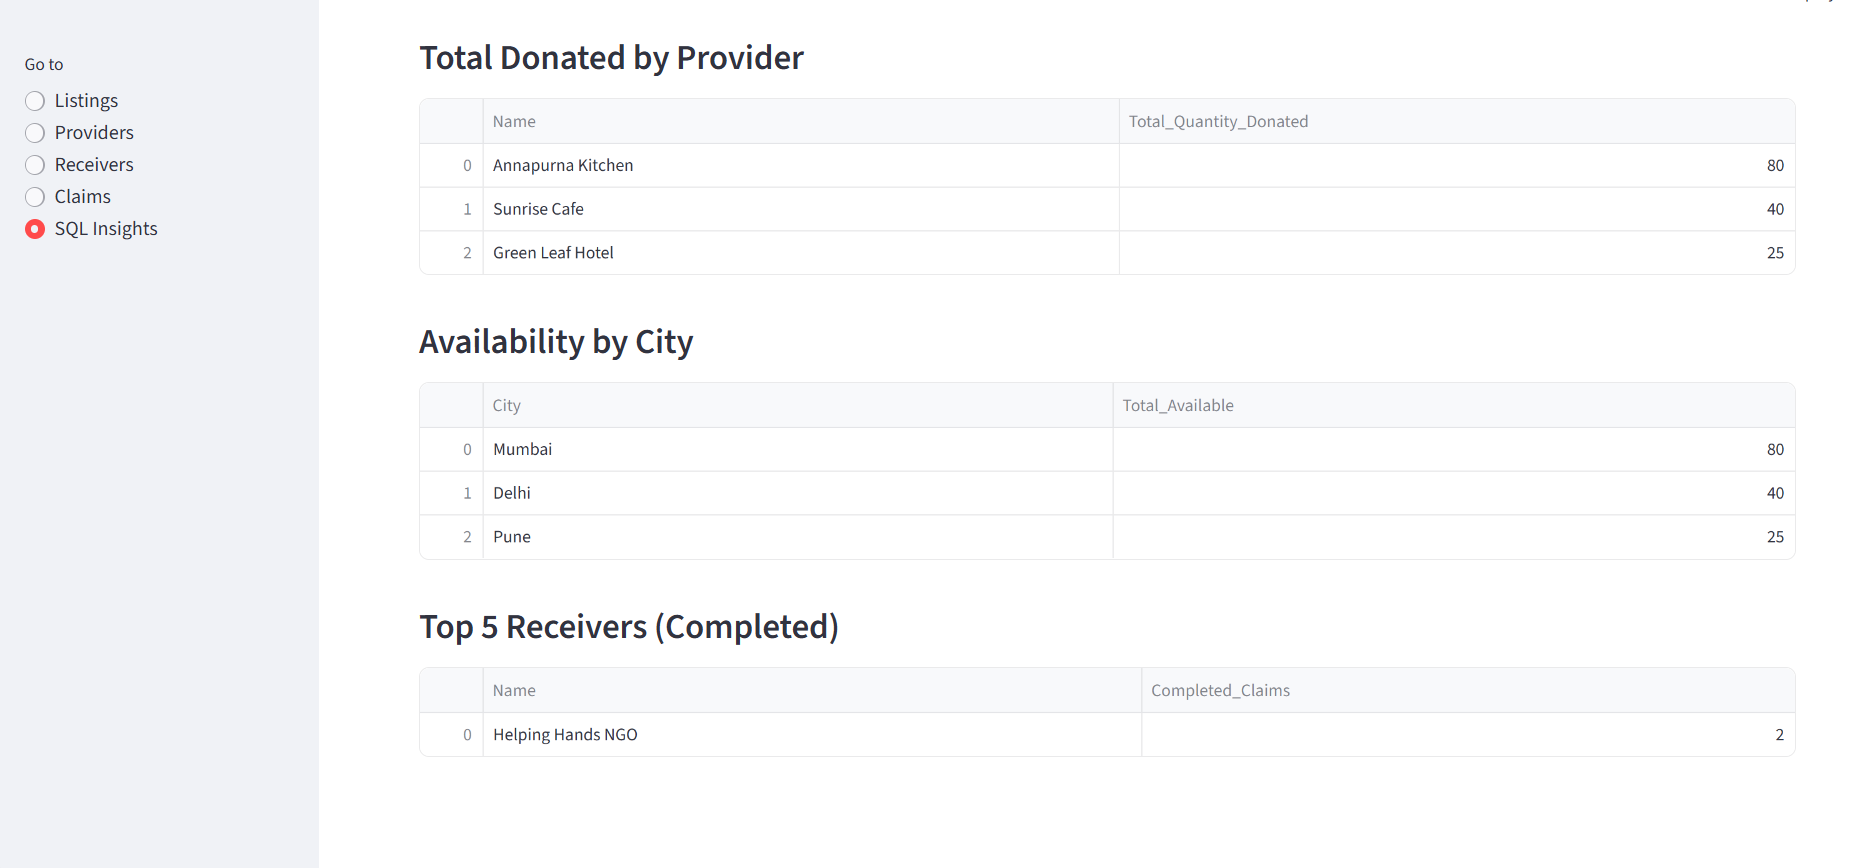

In [26]:
import os


os.chdir("C:\Labmentix\Project Folder")
print(os.getcwd())




from IPython.display import Image, display

# Path to your screenshots folder
folder = "screenshots"

# Loop through all files in the folder
for file in os.listdir(folder):
    if file.lower().endswith((".png", ".jpg", ".jpeg")):
        display(Image(os.path.join(folder, file)))

### Steps to run stramlit app

####

Step 1: Open Anaconda Prompt
Press Start → Anaconda Prompt.
Activate your environment :

conda activate myenv



Step 2: Go to Project Folder :
C:\Labmentix\Project Folder
    
    
Step 3: Create the Database

Run:
sqlite3 food_waste.db < schema.sql
sqlite3 food_waste.db < seed_data.sql


Step 4: Run the Streamlit App

Run:
streamlit run app.py



Step 6: Use the App
Navigate between tabs (Listings, Providers, Receivers, Claims, SQL Insights).
Apply filters, add/edit/delete entries, check insights.





